# Middleware

- control internals of the agent
- useful for the following:
    - tracking agent behavior : logging, analytics, debugging
    - transforming prompts, tool selection, output formatting
    - adding retried, fallbacks, early termination logic
    - applying rate limits, guardrails, PII detection 

In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

# Summarisation middleware

- Automatically summarizes conversational history when approaching token limits, preserving recent messages while compressing older context.
- useful for following:
    - long running conversations exceed context window
    - multiturn dialogues with extensive history
    - useful where full conversation context matters

## Messages

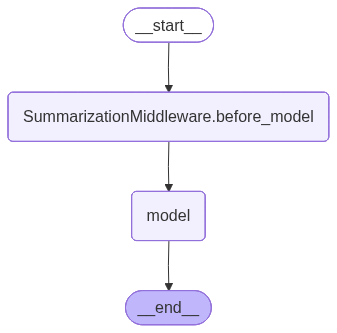

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

## Messagebased summarisation
agent = create_agent(
    model='groq:qwen/qwen3-32b',
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model='groq:qwen/qwen3-32b',
            trigger=('messages', 10),
            keep=('messages', 4)
        )
    ]
)

agent

In [11]:
# using thread id
config = {'configurable':{'thread_id':'test-1'}}


In [ ]:
qs = [
    'what is the radius of the moon?',
    'which is the biggest planet in the solar system?',
    'what is 67/32?',
    'what is 12+34?',
    'Is 9 prime of not?',
    'what is 12901*438?'
]

for q in qs:
    print(q)
    response=agent.invoke({"messages":[HumanMessage(content=q)]}, config)

    print(f"Messages: {response}")
    print(f'length of messages: {len(response['messages'])}')

## Tokens

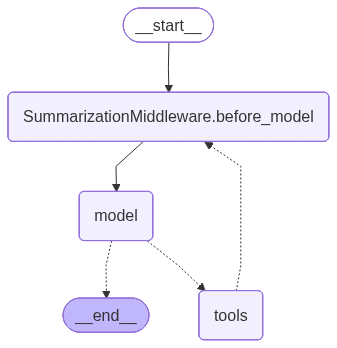

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city: str) -> str:
    """Search hotels - returns hotels in particular city"""
    return f"""Hotels in {city}:
    1. abc hotel - 5 star, $340/night, spa, pool, gym
    2. shf hotel - 4 star, $200/night, business center
    3. fdis stay - 3 star, $75/night, free wifi    
    """

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[search_hotel],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model='groq:qwen/qwen3-32b',
            trigger=('tokens', 550),
            keep=('tokens', 200)
        )
    ]
)

config = {'configurable': {'thread_id': 'test-1'}}

def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_char // 4

agent

In [ ]:
city = ['Paris', 'Tokyo', 'London', 'Moscow']

for c in city:
    response = agent.invoke(
        {
            'message': [HumanMessage(content=f'Find hotels in {city}')]
        },
        config = config
    )

    tokens = count_tokens(response['messages'])
    print(f'{city}: ~{tokens} tokens, {len(response['message'])} messages')
    print(response['messages'])

## Fractions

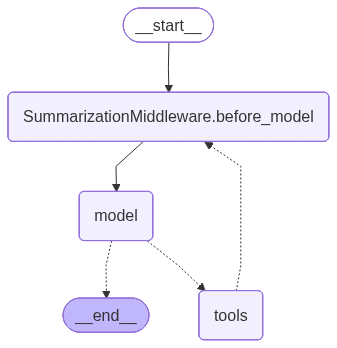

In [25]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city: str) -> str:
    """Search hotels - returns hotels in particular city"""
    return f"""Hotels in {city}: abc hotel - 5 star, $340/night, spa, pool, gym"""


agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[search_hotel],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model='groq:qwen/qwen3-32b',
            trigger=('fraction',0.005),
            keep=('fraction',0.002)
        )
    ]
)

config = {'configurable': {'thread_id': 'test-1'}}

def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_char // 4

agent

In [ ]:
city = ['Paris', 'Tokyo', 'London', 'Moscow']

for c in city:
    response = agent.invoke(
        {
            'message': [HumanMessage(content=f'Find hotels in {city}')]
        },
        config = config
    )

    tokens = count_tokens(response['messages'])
    fractions = tokens / 1280000
    print(f'{city}: ~{tokens} tokens ({fractions: .4%}), {len(response['message'])} messages')
    print(response['messages'])

# Human in the Loop Middleware

Pause agent execution for human approval, editing, rejection.

Useful for following:
- high stakes operations (database writes , financial transations)
- compliance workflows 
- long running conversations where human guides agent

In [30]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langgraph.types import Command

def read_email_tool(email_id: str) -> str:
    """mock function to read email by its email address"""
    return f"email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email"""
    return f'Email sent to {recipeint} with subject {subject} and body {body}'


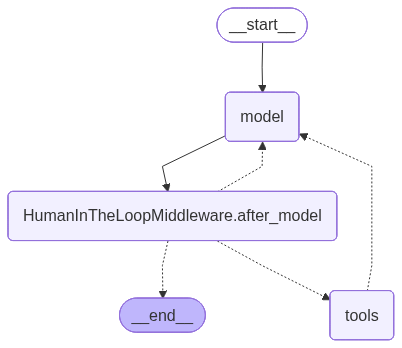

In [29]:
agent = create_agent(
    model='groq:qwen/qwen3-32b',
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    'allowed_decisions': ['approve', 'edit', 'reject']
                },
                'read_email_tool': False,
            }
        )
    ]
)

agent

In [ ]:
config = {'configurable': {'thread_id': 'test-approve1'}}

result = model.invoke(
    {
        'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]
    },
    config=config
)

In [ ]:
if "__interrupt__" in result:
    
    result = agent.invoke(
        Command(
            resume={
                'decisions': [
                    {'type': "approve"}
                ]
            }
        ),
        config = config
    )
    print('Result: ', result['messages'][-1].content)